In [1]:
import sys
from functools import partial
sys.path.append('../')
from math import log, comb, cos, sin
from numpy.linalg import matrix_power
from spd.OperatorSequence import *
from spd.SparsePauliDynamics import *
from spd.LightPauliDynamics import *
from pauli import *
from quantum_simulation_recipe.spin import Nearest_Neighbour_1d
from quantum_simulation_recipe.trotter import pf, expH
from qiskit.quantum_info import SparsePauliOp, random_statevector
import matplotlib.pyplot as plt
fig_dir, data_dir = './figs', './data'

In [53]:
n = 20 # 10
t = 2
r = 100 # 100
scale = 1

dt = t/r
H_model = 'MFI'
hx, hy, Jx = 1*scale, 0.9*scale, 0.8*scale
# n = 21
qimf = Nearest_Neighbour_1d(n, hx=hx, hy=hy, Jx=Jx, pbc=False)
xx_even = SparsePauliOp.from_sparse_list([*qimf.xx_tuples[::2]], num_qubits=n).simplify()
xx_odd  = SparsePauliOp.from_sparse_list([*qimf.xx_tuples[1::2]], num_qubits=n).simplify()
x_terms = SparsePauliOp.from_sparse_list([*qimf.x_tuples], num_qubits=n).simplify()
H_list = [x_terms, qimf.y_terms, xx_even, xx_odd] # [xx_even, x_terms, qimf.y_terms,xx_odd]
H_ordered = sum(H_list)
print(f't={t}, r={r}, dt={dt}')
init_state_str = '0'*n
# init_state_str = '10'*(n//2)

ops = dt*sum(H_list)
obs = qimf.ham
complete_fnorm = 2**(-n/2)*np.linalg.norm(obs.coeffs)
H_1norm = np.linalg.norm(obs.coeffs, ord=1)
print(f'Complete frobenius norm of H: {complete_fnorm:.4f}')
# print('Energy:', Statevector.from_label(init_state_str).data.conj() @ obs.to_matrix() @ Statevector.from_label(init_state_str).data)
# exp_val_func = partial(exp_val_0101_state_pauli_rep, n_qubits=n)
exp_val_func = exp_val_all_zeros_pauli_rep

t=2, r=100, dt=0.02
Complete frobenius norm of H: 0.0068


In [ ]:
w_thres = 3
sim = LowWeightPauliPropagation.from_pauli_list(obs, ops, threshold=w_thres, nprocs=8)
res = sim.run_dynamics(r, process=exp_val_func, process_every=1, verbose=False)
res = np.array(res)
# res = res / res[0].sum()

sim1 = LowWeightPauliPropagation.from_pauli_list(obs, ops, threshold=w_thres+1, nprocs=8)
res1 = sim1.run_dynamics(r, process=exp_val_func, process_every=1, verbose=False)
res1 = np.array(res1)

sim2 = LowWeightPauliPropagation.from_pauli_list(obs, ops, threshold=w_thres+2, nprocs=8)
res2 = sim2.run_dynamics(r, process=exp_val_func, process_every=1, verbose=False)
res2 = np.array(res2)

100%|██████████| 100/100 [1:03:19<00:00, 37.99s/it]


In [62]:
sim_2r = LowWeightPauliPropagation.from_pauli_list(obs, ops, threshold=w_thres, nprocs=8)
res_2r = sim_2r.run_dynamics(2*r, process=exp_val_func, process_every=1, verbose=False)

sim1_2r = LowWeightPauliPropagation.from_pauli_list(obs, ops, threshold=w_thres+1, nprocs=8)
res1_2r = sim1_2r.run_dynamics(2*r, process=exp_val_func, process_every=1, verbose=False)

sim2_2r = LowWeightPauliPropagation.from_pauli_list(obs, ops, threshold=w_thres+2, nprocs=8)
res2_2r = sim2_2r.run_dynamics(2*r, process=exp_val_func, process_every=1, verbose=False)

100%|██████████| 200/200 [1:46:33<00:00, 31.97s/it]  


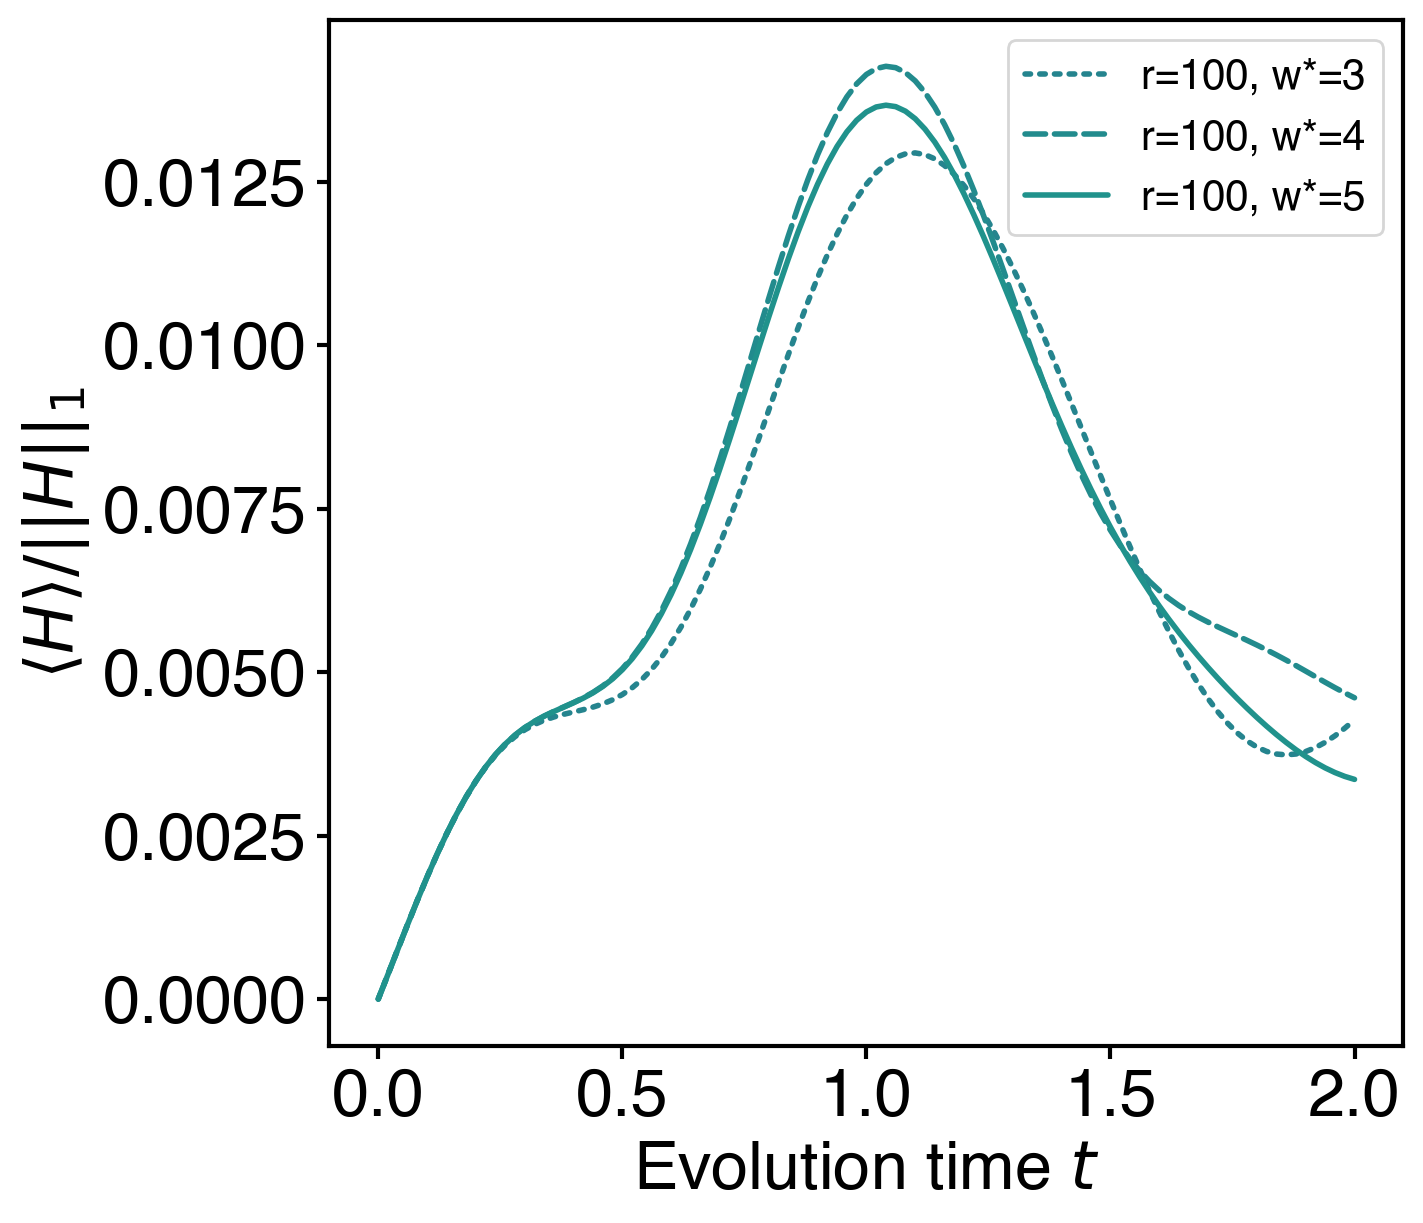

In [60]:
t_list = np.array(range(len(res))) * (t/r)
# t_list_2r = np.array(range(len(res_2r))) * (t/(2*r))
colors = plt.cm.viridis(np.linspace(0.4, 0.9, n))
# colors = plt.cm.plasma(np.linspace(0.3, 0.9, n))

fig, axes = plt.subplots(figsize=(7, 6), layout='constrained') # , layout='constrained'
axes.plot(t_list, res.real/H_1norm, ':', label=f'r={r}, w*={w_thres}', c=colors[w_thres-1])
axes.plot(t_list, res1.real/H_1norm, '--', label=f'r={r}, w*={w_thres+1}', c=colors[w_thres])
axes.plot(t_list, res2.real/H_1norm, '-', label=f'r={r}, w*={w_thres+2}', c=colors[w_thres+1])
# axes.plot(t_list_2r, res_2r.real/H_1norm, ':', label=f'r={2*r}, w*={w_thres}', c=colors[w_thres-1])
# axes.plot(t_list_2r, res1_2r.real/H_1norm, '--', label=f'r={2*r}, w*={w_thres+1}', c=colors[w_thres])
# axes.plot(t_list_2r, res2_2r.real/H_1norm, '--', label=f'r={2*r}, w*={w_thres+2}', c=colors[w_thres+1])
axes.set_xlabel(rf'Evolution time $t$'); 
axes.set_ylabel(rf'$\langle H \rangle/||H||_1$')
axes.legend(loc='best', fontsize='small')  # , ncol=1

fig.savefig(f'{fig_dir}/LPD_energy_{H_model}_n={n}_t={t}_r={r}_w={w_thres}_{init_state_str[:4]}.pdf', bbox_inches='tight')

## test steps

In [14]:
scale = 1
n = 10 # 10
t = 5 / scale
r = 200 # 100

dt = t/r
H_model = 'MFI'
hx, hy, Jx = 1*scale, 0.9*scale, 0.8*scale
# n = 21
qimf = Nearest_Neighbour_1d(n, hx=hx, hy=hy, Jx=Jx, pbc=False)
xx_even = SparsePauliOp.from_sparse_list([*qimf.xx_tuples[::2]], num_qubits=n).simplify()
xx_odd = SparsePauliOp.from_sparse_list([*qimf.xx_tuples[1::2]], num_qubits=n).simplify()
x_terms = SparsePauliOp.from_sparse_list([*qimf.x_tuples], num_qubits=n).simplify()
H_list = [x_terms, qimf.y_terms, xx_even, xx_odd] # [xx_even, x_terms, qimf.y_terms,xx_odd]
H_ordered = sum(H_list)
dt = t/r
print(f't={t}, r={r}, dt={dt}')
U_dt_ideal = expH(sum(H_ordered), dt, use_jax=False)
U_dt_appro = pf(H_ordered, dt, 1, 1)
# init_state_str = '0'*n
init_state_str = '10'*(n//2)
init_state = Statevector.from_label(init_state_str).data

z1 = SparsePauliOp('I'*(n-1)+'Z', 1)
complete_fnorm = 2**(-n/2)*np.linalg.norm(z1.to_matrix(), ord='fro')

t_num_dense = r
U_dt_ideal_dense = expH(sum(H_ordered), t/t_num_dense, use_jax=False)
ideal_expvals = [expect_value(z1.to_matrix(), matrix_power(U_dt_ideal_dense, i)@init_state) for i in range(t_num_dense+1)]
trott_expvals = [expect_value(z1.to_matrix(), matrix_power(U_dt_appro, i)@init_state) for i in range(r+1)]

trott_ops = [matrix_power(U_dt_appro, i) for i in range(r+1)]
ideal_ops = [matrix_power(U_dt_ideal, i) for i in range(r+1)]
trott_obs = [op.conjugate().transpose() @ z1.to_matrix() @ op for op in trott_ops]
ideal_obs = [op.conjugate().transpose() @ z1.to_matrix() @ op for op in ideal_ops]

ops = dt*sum(H_list)
obs = z1
print('ops:', ops)
print('obs:', obs)

exp_val_func = partial(exp_val_0101_state_pauli_rep, n_qubits=n)
# exp_val_func = exp_val_all_zeros_pauli_rep

w_thres = 3
sim = LowWeightPauliPropagation.from_pauli_list(obs, ops, threshold=w_thres, nprocs=4)
res = sim.run_dynamics(r, process=exp_val_func, process_every=1, verbose=False)
res = np.array(res)



t=5.0, r=200, dt=0.025
ops: SparsePauliOp(['IIIIIIIIIX', 'IIIIIIIIXI', 'IIIIIIIXII', 'IIIIIIXIII', 'IIIIIXIIII', 'IIIIXIIIII', 'IIIXIIIIII', 'IIXIIIIIII', 'IXIIIIIIII', 'XIIIIIIIII', 'IIIIIIIIIY', 'IIIIIIIIYI', 'IIIIIIIYII', 'IIIIIIYIII', 'IIIIIYIIII', 'IIIIYIIIII', 'IIIYIIIIII', 'IIYIIIIIII', 'IYIIIIIIII', 'YIIIIIIIII', 'IIIIIIIIXX', 'IIIIIIXXII', 'IIIIXXIIII', 'IIXXIIIIII', 'XXIIIIIIII', 'IIIIIIIXXI', 'IIIIIXXIII', 'IIIXXIIIII', 'IXXIIIIIII'],
              coeffs=[0.025 +0.j, 0.025 +0.j, 0.025 +0.j, 0.025 +0.j, 0.025 +0.j, 0.025 +0.j,
 0.025 +0.j, 0.025 +0.j, 0.025 +0.j, 0.025 +0.j, 0.0225+0.j, 0.0225+0.j,
 0.0225+0.j, 0.0225+0.j, 0.0225+0.j, 0.0225+0.j, 0.0225+0.j, 0.0225+0.j,
 0.0225+0.j, 0.0225+0.j, 0.02  +0.j, 0.02  +0.j, 0.02  +0.j, 0.02  +0.j,
 0.02  +0.j, 0.02  +0.j, 0.02  +0.j, 0.02  +0.j, 0.02  +0.j])
obs: SparsePauliOp(['IIIIIIIIIZ'],
              coeffs=[1.+0.j])


100%|██████████| 200/200 [00:02<00:00, 76.93it/s]


In [15]:
evo_obs = [item.to_sparse_pauli_op(n) for item in sim.evo_obs]
norm_weight_steps = []
for i, ob in enumerate(sim.evo_obs):
    temp_step = []
    # print(i, norm_weight_steps)
    for w in range(1, n+1):
        ob_w = decompose_by_weight_pauli_rep(ob)
        # print(ob_w)
        if w in ob_w:
            temp_step.append(ob_w[w].p2norm()**2)
        else:
            # print(f'No weight {w} Paulis')
            temp_step.append(0)
    norm_weight_steps.append(temp_step)

pauli_diff_fnorm = [2**(-n/2)*np.linalg.norm(ob.to_matrix() - trott_obs[i], ord='fro')/complete_fnorm for i, ob in enumerate(evo_obs)]
print(pauli_diff_fnorm)
trott_diff_fnorm = [2**(-n/2)*np.linalg.norm(ob - trott_obs[i], ord='fro')/complete_fnorm for i, ob in enumerate(ideal_obs)]

n_states = 100
haar_states = [random_statevector(2**n) for _ in range(n_states)]
# Verify 2-design property using Haar random states
expvals_pauli_diff = [[abs(states.expectation_value(ob.to_matrix() - trott_obs[i])) for states in haar_states] for i, ob in enumerate(evo_obs)]
expvals_trott_diff = [[abs(states.expectation_value(ob - trott_obs[i])) for states in haar_states] for i, ob in enumerate(ideal_obs)]

[0.0, 1.2499024511004342e-15, 2.7067282415725217e-15, 1.292782659282254e-07, 7.736133214814914e-07, 2.6986540067307183e-06, 7.167684966387257e-06, 1.6052087010141457e-05, 3.193284368737009e-05, 5.819148766248291e-05, 9.908890487571713e-05, 0.0001598304156816103, 0.00024661552909586374, 0.0003666707232560089, 0.0005282635525456947, 0.000740696335948074, 0.0010142776639061454, 0.0013602699981836496, 0.0017908117589568108, 0.002318812523299314, 0.0029578203239636804, 0.0037218605557387935, 0.004625246679260148, 0.005682363759381737, 0.0069074268761285685, 0.00831421757817449, 0.009915802777926171, 0.011724241770121081, 0.013750288341277847, 0.016003096169409748, 0.018489936834264226, 0.021215940711248795, 0.024183871754320935, 0.02739394763783603, 0.030843716885809593, 0.03452800443875925, 0.03843893657055628, 0.04256605515372811, 0.046896529967176456, 0.05141547602876583, 0.05610638079167103, 0.06095164342701, 0.06593322526233991, 0.07103340666321947, 0.076235641109452, 0.081525491780214

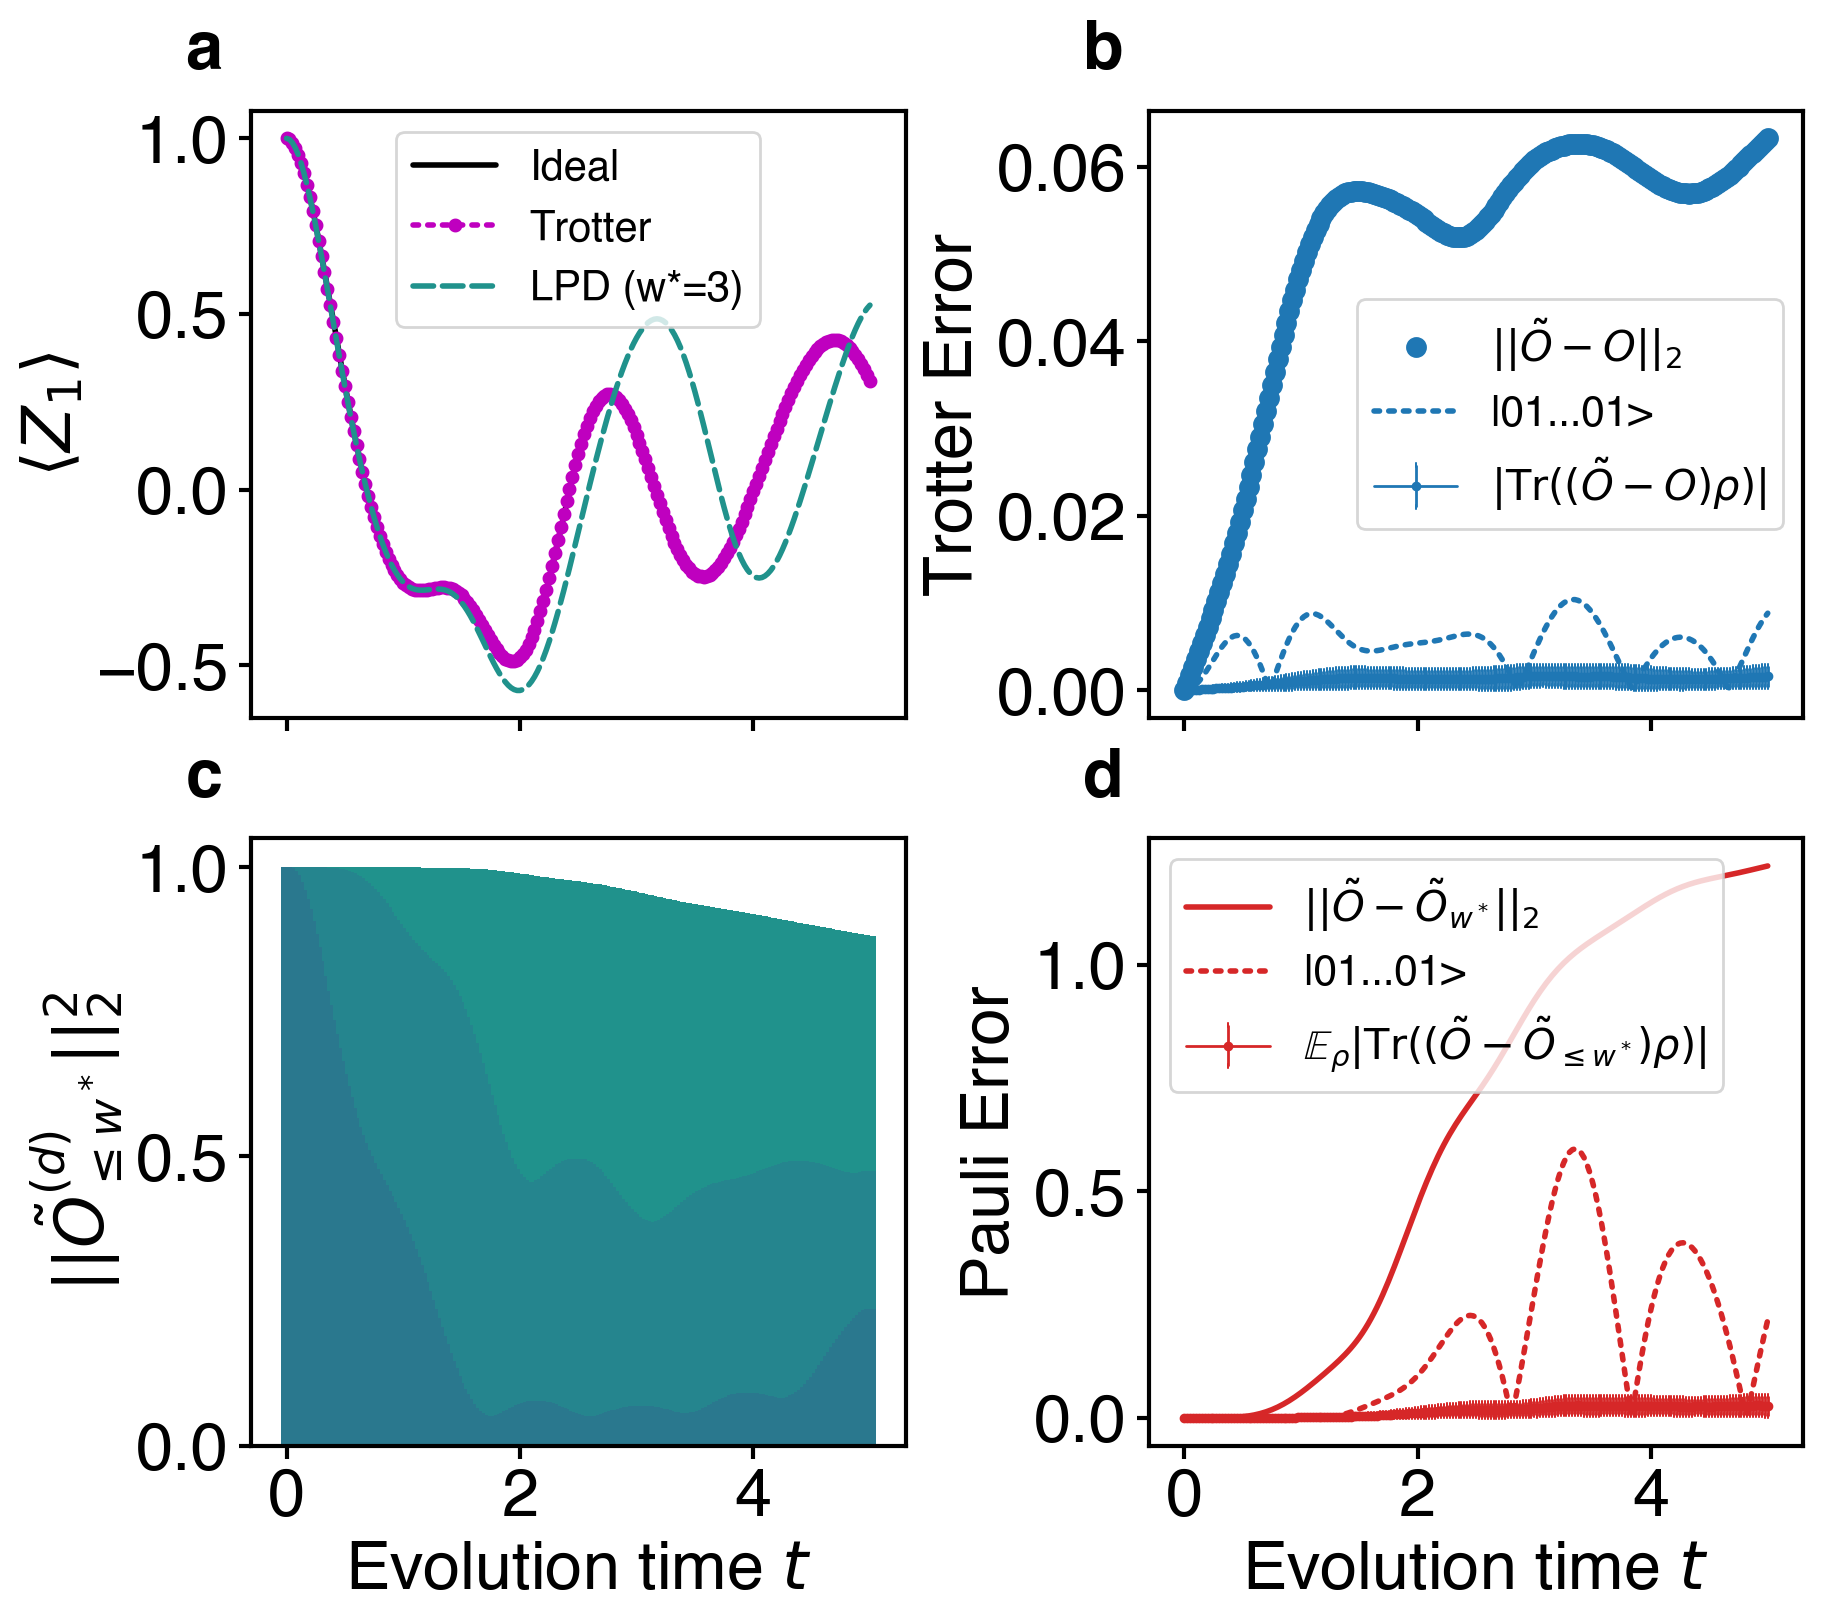

In [16]:
t_dense_list = np.array(range(len(ideal_expvals))) * t/t_num_dense
t_list = np.array(range(len(trott_expvals))) * dt
colors = plt.cm.viridis(np.linspace(0.4, 0.9, n))
# colors = plt.cm.plasma(np.linspace(0.3, 0.9, n))

fig, axes = plt.subplots(2, 2, sharex=True, figsize=(9, 8), layout='constrained') # , layout='constrained'
axes[0,0].plot(t_dense_list, ideal_expvals, '-', label='Ideal', c='k')
axes[0,0].plot(t_list, trott_expvals, ':.', label='Trotter', c='m', ms=6)
axes[0,0].plot(t_list, res.real, '--', label=f'LPD (w*={w_thres})', c=colors[w_thres-1])
axes[1,0].set_xlabel(rf'Evolution time $t$'); 
axes[0,0].set_ylabel(rf'$\langle Z_1 \rangle$')
axes[0,0].legend(loc='upper center', fontsize='small', ncol=1)
# axes[0,0].set_title(rf'{H_model}, n={n}, t={t}, r={r}, init={init_state_str[:2]}')

axes[1,1].plot(t_list, pauli_diff_fnorm, '-', label=r'$||\tilde{O}-\tilde{O}_{ w^*}||_2$', c='tab:red')
axes[1,1].errorbar(t_list, np.array(expvals_pauli_diff).mean(axis=1), yerr=np.array(expvals_pauli_diff).std(axis=1), fmt='.-', label=r'$\mathbb{E}_{\rho}|\text{Tr}((\tilde{O}-\tilde{O}_{\leq w^*})\rho)|$', c='tab:red', capsize=0.5, lw=1, ms=3)
axes[1,1].plot(t_list, abs(trott_expvals-res), ':', label=f'|01...01>', c='tab:red')
axes[1,1].set_ylabel(rf'Pauli Error'); axes[1,1].legend(loc='upper left', fontsize='small')
axes[1,1].set_xlabel(rf'Evolution time $t$'); 
axes[0,1].plot(t_list, trott_diff_fnorm, '.', label=r'$||\tilde{O}-O||_2$', c='tab:blue')
axes[0,1].errorbar(t_list, np.array(expvals_trott_diff).mean(axis=1), yerr=np.array(expvals_trott_diff).std(axis=1), fmt='.-', label=r'$|\text{Tr}((\tilde{O}-O)\rho)|$', c='tab:blue', capsize=0.5, lw=1, ms=3)
axes[0,1].plot(t_list, abs(np.array(trott_expvals)-np.array(ideal_expvals)), ':', label=f'|01...01>', c='tab:blue')
axes[0,1].set_ylabel(rf'Trotter Error'); axes[0,1].legend(loc='center right', fontsize='small')

for w in range(n, 0, -1):
    norm2_distr = [sum(norm_weight_steps[i][:w]) for i in range(len(trott_expvals))]
    # if w<=7: print(f'w>={w+1},', 1-norm2_distr[-1])
    bars = axes[1,0].bar(t_list, norm2_distr, 0.1, color=colors[w-1], label=f'w<={w}')
axes[1,0].set_ylabel(r'$||\tilde{O}_{\leq w^*}^{(d)}||_2^2$') # axes[1,0].legend(loc='upper right')

for ax, label in zip(axes.flatten(), ['a', 'b', 'c', 'd']): 
    ax.text(-0.10, 1.15, label, transform=ax.transAxes, fontsize=24, va='top', weight='bold')

fig.savefig(f'{fig_dir}/LPD_test_r={r}_n={n}_w={w_thres}.pdf', bbox_inches='tight')
# fig.savefig(f'{fig_dir}/LPD_{H_model}_n={n}_t={t}_r={r}_w={w_thres}_{init_state_str[:4]}.pdf', bbox_inches='tight')